In [1]:
import numpy as np

from typing import List

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Magic 😁
%matplotlib inline

plt.close("all")


/home/abduaziz/.local/lib/python3.8/site-packages/pandas/compat/__init__.py:124: UserWarning: Could not import the lzma module. Your installed Python is incomplete. Attempting to use lzma compression will result in a RuntimeError.
  warnings.warn(msg)


Reading dataset from `csv` file using pandas' `read_csv` method.

In [2]:
movie_df = pd.read_csv("tmdb-movies.csv")

We should know the number of rows and columns. Method `shape`, returns all of these in one python tuple.

In [3]:
movie_df.shape

(10866, 21)

Check data frame for duplicate values. We can do this by simple `sum` function that returns 0 if there are no duplicates but else  it should return 1

In [4]:
# sum -python's built-in function
sum(movie_df.duplicated())

1

Oh man, there are some duplicates. But we can remove them easily by using pandas' simple data frame method!
The best reference which I have ever seen:
* https://towardsdatascience.com/finding-and-removing-duplicate-rows-in-pandas-dataframe-c6117668631f

In [5]:
movie_df.drop_duplicates(inplace=True)

I have to make sure that there are not negative values on popularity of movies. If all is "ok", it should return `True`

In [6]:
movie_df.popularity.min() > 0 and movie_df.popularity.max() > 0

True

References which I used:
*  https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html?highlight=drop#pandas.DataFrame.drop

In [7]:
# We have defined labels that should be dropped
labels_for_drop: List[str] = [
    "imdb_id", "cast", "homepage",
    "tagline", "director", "keywords",
    "overview", "release_date","id"
]

movie_df.drop(
    labels=labels_for_drop,
    inplace=True,
    axis=1
)

`nan` - numpy's nan, representation of Not a Number. If you are familar with JS, you should know about this 😁

`dropna` - removes missing values from data frame.

References which I used:
*   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
*  https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html?highlight=replace#pandas.DataFrame.replace

In [8]:
movie_df = movie_df.replace(0, np.nan)
movie_df = movie_df.dropna()

# see all information about DF.
movie_df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 3808 entries, 0 to 10848
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   popularity            3808 non-null   float64
 1   budget                3808 non-null   float64
 2   revenue               3808 non-null   float64
 3   original_title        3808 non-null   object 
 4   runtime               3808 non-null   float64
 5   genres                3808 non-null   object 
 6   production_companies  3808 non-null   object 
 7   vote_count            3808 non-null   int64  
 8   vote_average          3808 non-null   float64
 9   release_year          3808 non-null   int64  
 10  budget_adj            3808 non-null   float64
 11  revenue_adj           3808 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 386.8+ KB


# **Q1: The Number of films in each year are increasing?**

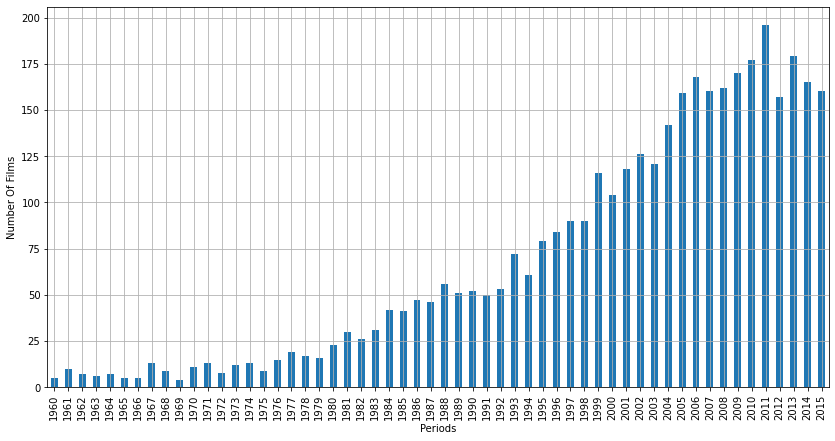

In [9]:
def make_series(dataframe: pd.DataFrame, column: str) -> pd.Series:
    # returns pd.Series object by sorting it
    return dataframe[column].value_counts().sort_index()

# I looks very good with grid
make_series(movie_df, "release_year").plot(
    grid=True,
    kind='bar',
    figsize=(14, 7)
)

plt.xlabel("Periods")
plt.ylabel("Number Of Films")

plt.savefig("charts/chart_1.jpg")

We can see, this bar graph shows that the greatest values are in between 2009 and 2014

# **Q2: The rating of movies increasing or decreasing year by year?**

First of all, we need to know better about average ratings. For this, we have to calculate only the mean of DF. Before this, we should group the dataframe by its release year and after this, we can calculate its `vote_average`'s mean by selecting this column.

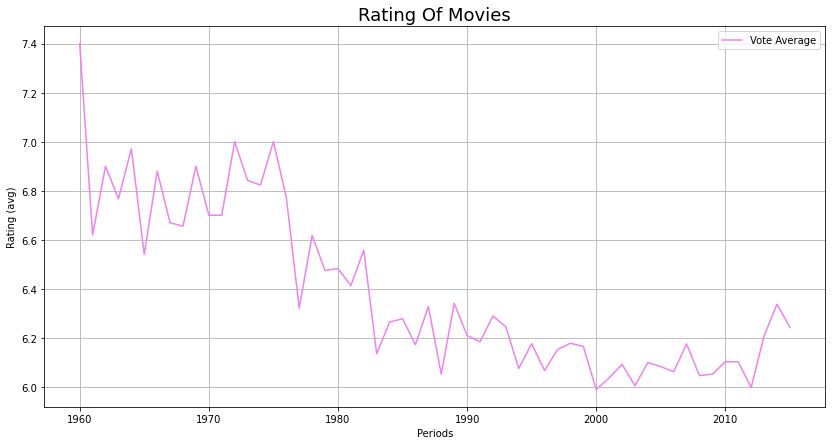

In [10]:
chart_cfg = dict(
    grid=True,
    kind='line',
    color='violet',
    figsize=(14, 7),
)


def calc_mean(
    dataframe: pd.DataFrame,
    gr_column: str,
    column: str
) -> pd.DataFrame:
    """
    :param: gr_column - a column which you want to use to group
    """
    return dataframe.groupby(gr_column)[column].mean()


calc_mean(
    movie_df,
    'release_year',
    'vote_average'
).plot(**chart_cfg).legend(['Vote Average'])

plt.xlabel("Periods")
plt.ylabel("Rating (avg)")

plt.title("Rating Of Movies", fontsize=18)

plt.savefig("charts/chart_2.jpg")


# **Q3: Movies with greatest and least budget**

In [11]:
def get_greatest_and_lowest(dataframe: pd.DataFrame, column: str) -> pd.DataFrame:
    # By using .loc() method, we can access group of rows & columns
    # idmax() - returns row label which has maximum value
    # idmin() - returns row label which has minimum value

    greatest_df = pd.DataFrame(
        dataframe.loc[
            dataframe[column].idxmax()
        ]
    )

    least_df = pd.DataFrame(
        dataframe.loc[
            dataframe[column].idxmin()
        ]
    )
    # concat method for `joining` two dataframes
    return pd.concat([greatest_df, least_df], axis=1)


get_greatest_and_lowest(movie_df, "revenue")


,1386,5067
popularity,9.432768,0.462609
budget,237000000.0,6000000.0
revenue,2781505847.0,2.0
original_title,Avatar,Shattered Glass
runtime,162.0,94.0
genres,Action|Adventure|Fantasy|Science Fiction,Drama|History
production_companies,Ingenious Film Partners|Twentieth Century Fox ...,Lions Gate Films|Cruise/Wagner Productions|Bau...
vote_count,8458,46
vote_average,7.1,6.4
release_year,2009,2003


# **Q4: Which genre has more movies than others?**

First of all, we should collect all genres from `movie_df`.
Also we should do this:
```
"A|B|C" => ["A","B","C"]
```
We can do this easily by using the simple `split` method!

In [12]:
genres:List[str] = movie_df['genres'].str.cat(sep="|").split('|')
genres[0:20]

['Action',
 'Adventure',
 'Science Fiction',
 'Thriller',
 'Action',
 'Adventure',
 'Science Fiction',
 'Thriller',
 'Adventure',
 'Science Fiction',
 'Thriller',
 'Action',
 'Adventure',
 'Science Fiction',
 'Fantasy',
 'Action',
 'Crime',
 'Thriller',
 'Western',
 'Drama']

Ok, we have list of all genres. The task that we should done is find genre which has a more movies than other genres. We can use `mode` function from `statistics` module:

In [13]:
from statistics import mode
mode(genres)

'Drama'

In [14]:
# dimensional array of genres
genres_ndarray = pd.Series(genres).value_counts()
# see it
genres_ndarray

Drama              1731
Comedy             1336
Thriller           1195
Action             1076
Adventure           743
Romance             659
Crime               649
Science Fiction     517
Horror              459
Family              417
Fantasy             395
Mystery             343
Animation           199
Music               132
History             128
War                 119
Western              52
Documentary          28
Foreign              10
TV Movie              1
dtype: int64

Huh! There are almost 1.8k movies in `Drama`, that is great! Now, we found an answer to our 4th question. However, we can try to build a pie chart for illustrating this. For doing this, we can use the array which we defined below as `genres`

* https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.pie.html
* https://stackoverflow.com/questions/11927715/how-to-give-a-pandas-matplotlib-bar-graph-custom-colors

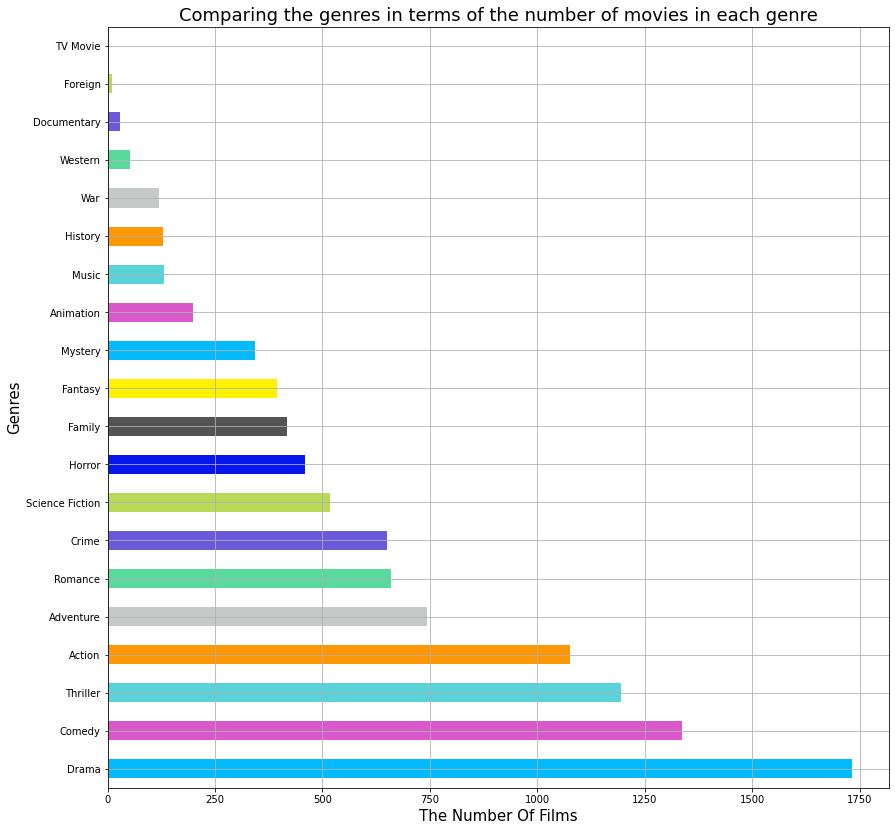

In [15]:
# Imports for generating colors.
from itertools import cycle
from itertools import islice

chart_cfg = {
    "grid": True,
    "kind": "barh",
    "figsize": (14, 14),
    # solution from StackOverflow :)
    'color': list(
        islice(
            cycle(
                [
                    '#03bafc', '#d959ca', '#59d2d9',
                    '#fc9803', "#c5c9c8", '#59d99b',
                    "#6a59d9", "#b9d959", "#0716ed",
                    "#545454", "#fff200"
                ]
            ), None, len(genres)
        )
    )
}

plt.xlabel('The Number Of Films', fontsize=15)
plt.ylabel('Genres', fontsize=15)

plt.title(
    "Comparing the genres in terms of the number of movies in each genre",
    fontsize=18
)

genres_ndarray.plot(**chart_cfg)

plt.savefig("charts/chart_3.jpg")


Pie chart also

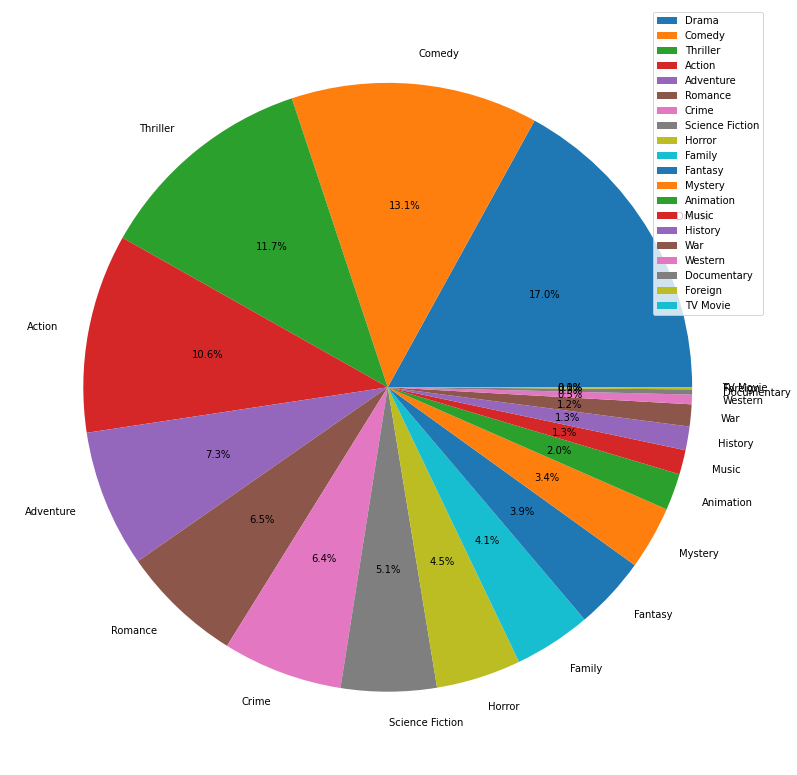

In [16]:
chart_cfg = {
    "grid": True,
    "kind": 'pie',
    "legend": True,
    "figsize": (14, 14),
    # For showing percentages, I had to use it. 
    # I found it from internet :)
    # https://stackoverflow.com/questions/6170246/how-do-i-use-matplotlib-autopct
    "autopct": "%1.1f%%",
}

genres_ndarray.plot(**chart_cfg)

plt.ylabel('') # we need not y label

plt.savefig("charts/chart_4.jpg")


# **Q5:How long average duration of the films?**

For finding answer to this question, we can use pandas' hist method of DF.

* https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html

*I have learnt more information about hist's arguments on reference Which I mentioned above*

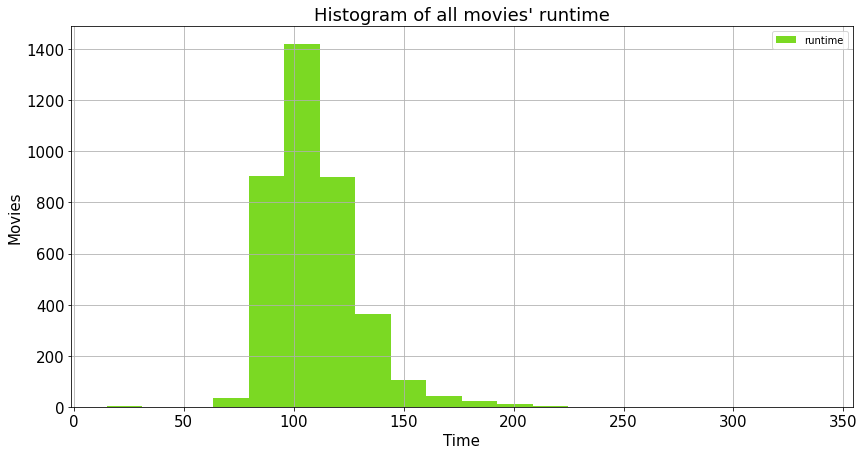

In [17]:
chart_cfg = {
    "bins": 20,
    "legend": True,
    "xlabelsize": 15,
    "ylabelsize": 15,
    "color": "#7bd923",
    "figsize": (14, 7),
}

plt.title("Histogram of all movies' runtime", fontsize=18)

plt.xlabel("Time", fontsize=15)
plt.ylabel("Movies", fontsize=15)

movie_df['runtime'].hist(**chart_cfg,)

plt.savefig("charts/chart_5.jpg")


Furthermore, we can calculate average runtime by simple describe method of pandas' DF!

In [18]:
movie_df.describe()['runtime']

count    3808.000000
mean      109.362395
std        19.855757
min        15.000000
25%        96.000000
50%       106.000000
75%       119.000000
max       338.000000
Name: runtime, dtype: float64

# **Q6: What kinds of properties are associated with movies that have high revenues?**

I want to visualize `budgets` and `profits` columns to make new findings for this research question.

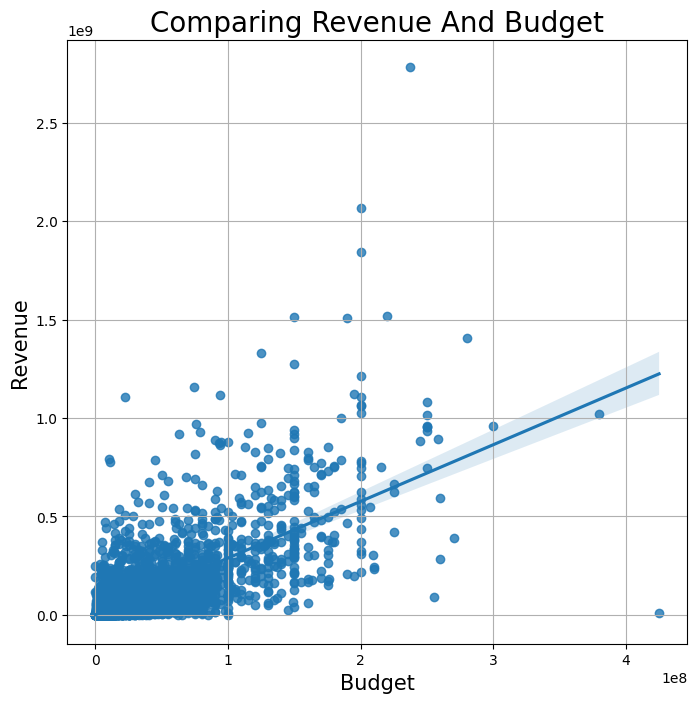

In [24]:
def make_regplot(
    dataframe: pd.DataFrame,
    first_column: str,
    second_column: str
):
    # we have to give two arguments to building regplot
    return sns.regplot(
        x=dataframe[first_column], y=dataframe[second_column],
    )

plot = make_regplot(
    movie_df, 'budget', 'revenue'
)

# title with custom fontsize
plot.set_title("Comparing Revenue And Budget",fontsize=20)

# we need to our plot have a grid
plt.grid()

# we need to be bigger plot :)
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['figure.dpi'] = 100

plt.xlabel("Budget",fontsize=15)
plt.ylabel("Revenue",fontsize=15)

plt.show()

plot.get_figure().savefig("charts/chart_6.jpg")


In this plot, we can see the relationship between budgets and revenues of movies and I want to write about my findings below.

# **My Findings**

* **[Q1]** The number of movies is significantly increased over all of the period.
    * The maximum movies are released in 2011 (196)
    * Approximately 68 movies releases year by year and these numbers are increasing

In [20]:
movie_df[
    'release_year'
].value_counts().sort_values(ascending=False).head(1)


2011    196
Name: release_year, dtype: int64

In [21]:
print('Average of movies is {}'.format(
    int(
        movie_df['release_year'].value_counts().mean()
    )
))

Average of movies is 68


* **[Q2]** The rating of movies are decreasing year from the beginning of the period and they are dropped almost by 1.0.
  * The lowest rating showed in 2000 and 2010.

* **[Q3]** The highest profit made by `Avatar` and lowest `Shattered Glass`

* **[Q4]** The genre of `Drama` has significantly more movies than others

* **[Q5]** The average runtime for movies is **109** min. 
    * Maximum and Minimum runtime is **338** and **15** min.
    * Almost 25% of films have runtime roughly **96** min
    * Almost 50% of films have runtime roughly **106** min
    * Almost 75% of films have runtime roughly **119** min 

* **[Q6]** There is no doubt that the budget of a movie has a very good impact on having good profit. According to the plot given above, we can conclude that movies that have more budget movies become the most profitable movies. The `budget` of movies is the thing that is important to have high revenues.

# **Limitations**

*   I have found a lot of rows with zero values on revenues and budgets related rows.
*   There are some incorrect data types on the movies dataset
*   Duplicates are so a lot that it has a negative effects analysis' results
*   There is no information about the currency of revenues and other columns like that.